Columns in dataset:
Index(['Major_code', 'Major', 'Major_category', 'Total', 'Employed',
       'Employed_full_time_year_round', 'Unemployed', 'Unemployment_rate',
       'Median', 'P25th', 'P75th'],
      dtype='str')

Using text column: Major
Using numeric column: Major_code

Cluster sizes:
cluster
2    58
1    38
3    34
0    30
4    13
Name: count, dtype: int64

Sample texts per cluster:
cluster     
0        88                                 NEUROSCIENCE
         92              STATISTICS AND DECISION SCIENCE
         81                            MOLECULAR BIOLOGY
1        137    TRANSPORTATION SCIENCES AND TECHNOLOGIES
         164            MARKETING AND MARKETING RESEARCH
         138                                   FINE ARTS
2        61                     ENGINEERING TECHNOLOGIES
         15                                   MASS MEDIA
         48                       ELECTRICAL ENGINEERING
3        115                      EDUCATIONAL PSYCHOLOGY
         120          

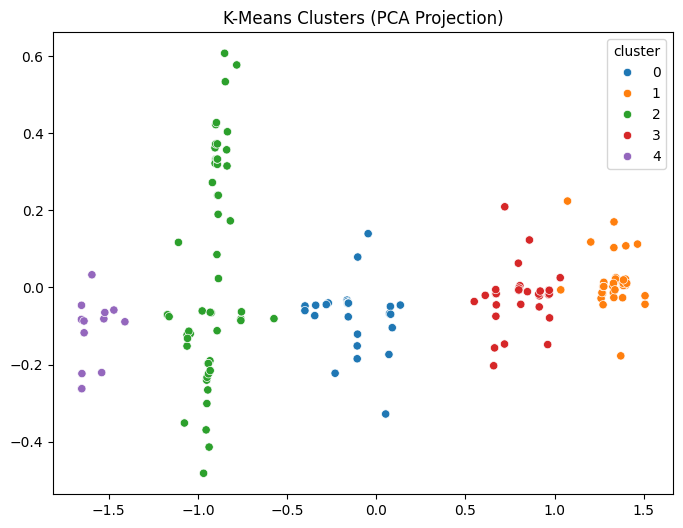

In [4]:
# =========================
# Step 1: Imports
# =========================
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Step 2: Load dataset
# =========================
df = pd.read_csv('all-ages.csv')

print("Columns in dataset:")
print(df.columns)

# =========================
# Step 3: Auto-detect columns (FIXED + FUTURE PROOF)
# =========================

# ---- Detect text column ----
possible_text_cols = ['text', 'review', 'description', 'content', 'comment']
text_col = None

for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    text_cols = df.select_dtypes(include=['object', 'string']).columns
    if len(text_cols) == 0:
        raise ValueError("No text column found in dataset.")
    text_col = text_cols[0]

# ---- Detect numeric column ----
possible_num_cols = ['age', 'value', 'score', 'rating']
num_col = None

for col in possible_num_cols:
    if col in df.columns:
        num_col = col
        break

if num_col is None:
    num_cols = df.select_dtypes(include=np.number).columns
    if len(num_cols) == 0:
        raise ValueError("No numeric column found in dataset.")
    num_col = num_cols[0]

print(f"\nUsing text column: {text_col}")
print(f"Using numeric column: {num_col}")

# =========================
# Step 4: Clean text
# =========================
text_data = df[text_col].fillna("").astype(str)

# =========================
# Step 5: TF-IDF Vectorization
# =========================
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
text_features = tfidf.fit_transform(text_data)

# =========================
# Step 6: Scale numeric feature
# =========================
scaler = StandardScaler()

num_data = df[[num_col]].fillna(0)
num_features = scaler.fit_transform(num_data)

# =========================
# Step 7: Combine features
# =========================
X = hstack([text_features, num_features])

# =========================
# Step 8: K-Means Clustering
# =========================
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X)

# =========================
# Step 9: Cluster analysis
# =========================
print("\nCluster sizes:")
print(df['cluster'].value_counts())

print("\nSample texts per cluster:")
print(
    df.groupby('cluster')[text_col]
    .apply(lambda x: x.sample(min(3, len(x)), random_state=1))
)

# =========================
# Step 10: PCA Visualization
# =========================
pca = PCA(n_components=2, random_state=42)

# Convert sparse -> dense (required for PCA)
X_dense = X.toarray()
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['cluster'],
    palette='tab10'
)

plt.title('K-Means Clusters (PCA Projection)')
plt.show()